# 🩺 Breast Cancer Classification using a Simple CNN

## Overview
This notebook implements a **Convolutional Neural Network (CNN)** to classify breast cancer histopathology images into two categories:
- **Class 0** → Non-IDC (No Invasive Ductal Carcinoma)
- **Class 1** → IDC (Invasive Ductal Carcinoma)

## Pipeline Summary
| Step | Description |
|------|-------------|
| 1 | Load image paths and labels from the dataset directory |
| 2 | Split data by patient into Train / Val / Test sets |
| 3 | Define a PyTorch `Dataset` class to serve images |
| 4 | Build a simple 3-layer CNN model |
| 5 | Train the model with epoch-level progress tracking (tqdm) |
| 6 | Evaluate on the held-out test set |
| 7 | Plot Loss and Accuracy curves |

## Dataset Structure
```
Data/Breast_Cancer/
    └── <patient_id>/
            ├── 0/   ← Non-IDC patches (.png)
            └── 1/   ← IDC patches (.png)
```

> **Note:** Each image patch is 50×50 pixels (RGB). Splits are done **per patient** to prevent data leakage.

---
## 📦 Section 1: Imports & Device Setup

We import all required libraries and detect whether a **GPU** is available.
Training will automatically run on the GPU if present, otherwise it falls back to the CPU.

| Library | Purpose |
|---------|--------|
| `os`, `pandas`, `numpy` | File I/O and data manipulation |
| `matplotlib` | Plotting loss and accuracy curves |
| `PIL` | Loading PNG images |
| `sklearn` | Patient-level train/val/test split |
| `torch`, `torchvision` | Model definition, training, and image transforms |
| `tqdm` | Real-time epoch progress bar during training |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from tqdm import tqdm

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 📁 Section 2: Dataset Path Configuration

Set the root path to the Breast Cancer dataset directory.
All patient subfolders with their class-labeled image patches reside under this path.

In [2]:
base_path = "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images"

---
## 🗂️ Section 3: Data Loading & Splitting

### 3.1 `load_data(base_path)`
Walks the dataset directory tree and collects every `.png` image path along with its label (0 or 1).
Returns a `DataFrame` with columns: `patient_id`, `image_path`, `label`.

### 3.2 `split_data(df)`
Splits the data **by patient** (not by image) to avoid data leakage between splits.

| Split | Patients | Purpose |
|-------|----------|---------|
| Train | 70% | Model weight updates |
| Val   | 15% | Hyperparameter tuning & early stopping |
| Test  | 15% | Final unbiased evaluation |

In [3]:
# ============================================================================
# STEP 1: PREPARE DATA
# ============================================================================

def load_data(base_path):
    """Load all image paths and labels into a DataFrame"""
    print("Loading data...")
    data = []
    
    for patient in os.listdir(base_path):
        patient_path = os.path.join(base_path, patient)
        if os.path.isdir(patient_path):
            # Class 0 = Non-IDC, Class 1 = IDC
            for class_folder in ['0', '1']:
                class_path = os.path.join(patient_path, class_folder)
                if os.path.exists(class_path):
                    for img_name in os.listdir(class_path):
                        if img_name.endswith('.png'):
                            data.append({
                                'patient_id': patient,
                                'image_path': os.path.join(class_path, img_name),
                                'label': int(class_folder)
                            })
    
    df = pd.DataFrame(data)
    print(f"✓ Loaded {len(df)} images from {df['patient_id'].nunique()} patients")
    print(f"  Class 0 (Non-IDC): {(df['label']==0).sum()} images")
    print(f"  Class 1 (IDC):     {(df['label']==1).sum()} images")
    return df

In [4]:
def split_data(df):
    """Split data by patient into train/val/test sets"""
    print("\nSplitting data...")
    
    # Get unique patients
    unique_patients = df['patient_id'].unique()
    
    # Split patients: 70% train, 15% val, 15% test
    train_patients, temp = train_test_split(unique_patients, test_size=0.3, random_state=42)
    val_patients, test_patients = train_test_split(temp, test_size=0.5, random_state=42)
    
    # Create dataframes
    train_df = df[df['patient_id'].isin(train_patients)].reset_index(drop=True)
    val_df = df[df['patient_id'].isin(val_patients)].reset_index(drop=True)
    test_df = df[df['patient_id'].isin(test_patients)].reset_index(drop=True)
    
    print(f"✓ Train: {len(train_df)} images ({len(train_patients)} patients)")
    print(f"✓ Val:   {len(val_df)} images ({len(val_patients)} patients)")
    print(f"✓ Test:  {len(test_df)} images ({len(test_patients)} patients)")
    
    return train_df, val_df, test_df

---
## 🖼️ Section 4: PyTorch Dataset Class

The `BreastCancerDataset` class wraps the DataFrame and exposes it to a PyTorch `DataLoader`.

| Method | Description |
|--------|-------------|
| `__len__` | Returns the total number of images in the split |
| `__getitem__` | Opens a single image by index, converts to RGB, applies transforms, and returns `(image_tensor, label)` |

Transforms applied:
1. **Resize** to 50×50 pixels
2. **ToTensor** — converts PIL image to a `[C, H, W]` float tensor in `[0, 1]`
3. **Normalize** — rescales each channel to `[-1, 1]` using `mean=0.5, std=0.5`

In [5]:
# ============================================================================
# STEP 2: CREATE DATASET CLASS
# ============================================================================

class BreastCancerDataset(Dataset):
    """Dataset class to load images"""
    
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Get image path and label
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

---
## 🧠 Section 5: CNN Model Architecture

The `SimpleCNN` consists of **3 convolutional blocks** followed by **2 fully-connected layers**.

### Architecture Diagram
```
Input (3, 50, 50)
    │
    ▼
[Conv2d 3→32, 3×3] → ReLU → MaxPool2d(2)   →  (32, 25, 25)
    │
    ▼
[Conv2d 32→64, 3×3] → ReLU → MaxPool2d(2)  →  (64, 12, 12)
    │
    ▼
[Conv2d 64→128, 3×3] → ReLU → MaxPool2d(2) →  (128, 6, 6)
    │
    ▼
Flatten → (128 × 6 × 6 = 4608)
    │
    ▼
[Linear 4608→256] → ReLU → Dropout(0.5)
    │
    ▼
[Linear 256→2]  ← Output logits (Non-IDC | IDC)
```

| Layer | Type | Input → Output | Notes |
|-------|------|----------------|-------|
| conv1 | Conv2d | 3 → 32 ch | 3×3 kernel, padding=1 |
| conv2 | Conv2d | 32 → 64 ch | 3×3 kernel, padding=1 |
| conv3 | Conv2d | 64 → 128 ch | 3×3 kernel, padding=1 |
| pool  | MaxPool2d | — | 2×2 stride |
| fc1   | Linear | 4608 → 256 | ReLU + Dropout(0.5) |
| fc2   | Linear | 256 → 2 | Logits for CE loss |

In [6]:
# ============================================================================
# STEP 3: SIMPLE CNN MODEL
# ============================================================================

class SimpleCNN(nn.Module):
    """Simple CNN for breast cancer classification"""
    
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # 3 Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, 2)  # 2 classes: 0 and 1
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        # Conv layers with ReLU and pooling
        x = self.pool(F.relu(self.conv1(x)))  # 50x50 -> 25x25
        x = self.pool(F.relu(self.conv2(x)))  # 25x25 -> 12x12
        x = self.pool(F.relu(self.conv3(x)))  # 12x12 -> 6x6
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

---
## 🔁 Section 6: Training & Validation Functions

### 6.1 `train_one_epoch`
Runs a full pass over the training `DataLoader`:
1. Moves batch to the target device (GPU/CPU)
2. Computes the forward pass → loss
3. Backpropagates gradients → updates weights
4. Accumulates loss and counts correct predictions

Returns: `(avg_loss, accuracy%)` for the epoch.

### 6.2 `validate`
Runs inference over a `DataLoader` with **`torch.no_grad()`** (no gradient computation).
Used for both validation and final test evaluation.

Returns: `(avg_loss, accuracy%)` for the split.

In [7]:
# ============================================================================
# STEP 4: TRAINING FUNCTIONS
# ============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch and return loss and accuracy"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

In [8]:
def validate(model, dataloader, criterion, device):
    """Validate model and return loss and accuracy"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

---
## 📊 Section 7: Results Visualization

The `plot_results` function generates a side-by-side figure after training completes:

| Plot | X-axis | Y-axis | Lines |
|------|--------|--------|-------|
| Left | Epoch | Loss | Train Loss (blue), Val Loss (red) |
| Right | Epoch | Accuracy (%) | Train Acc (blue), Val Acc (red), Test Acc dashed (green) |

A final **summary table** is printed with the last epoch's Train/Val accuracy and the Test accuracy.

In [9]:
# ============================================================================
# STEP 6: VISUALIZATION
# ============================================================================

def plot_results(train_losses, val_losses, train_accs, val_accs, test_acc):
    """Plot training results"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(train_losses) + 1)
    
    # Plot Loss
    ax1.plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-o', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(epochs, train_accs, 'b-o', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-o', label='Validation Accuracy', linewidth=2)
    ax2.axhline(y=test_acc, color='g', linestyle='--', linewidth=2, 
                label=f'Test Accuracy = {test_acc:.2f}%')
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"Final Training Accuracy:   {train_accs[-1]:.2f}%")
    print(f"Final Validation Accuracy: {val_accs[-1]:.2f}%")
    print(f"Test Accuracy:             {test_acc:.2f}%")
    print("="*70)

---
## 🚀 Section 8: Main Training Pipeline

The `train_model` function orchestrates the entire end-to-end pipeline:

| Sub-step | What happens |
|----------|--------------|
| 1 | `load_data` + `split_data` |
| 2 | Define image transforms (Resize → ToTensor → Normalize) |
| 3 | Wrap DataFrames in `BreastCancerDataset` |
| 4 | Create `DataLoader` objects (shuffle train, no shuffle val/test) |
| 5 | Instantiate `SimpleCNN`, move to device |
| 6 | Loss = `CrossEntropyLoss`, Optimizer = `Adam(lr=0.001)` |
| 7 | Epoch loop with **tqdm** progress bar showing real-time loss & accuracy |
| 8 | Save best model checkpoint to `Models/Breast_Cancer.pth` |
| 9 | Load best weights → evaluate on test set → plot results |

### Hyperparameters
| Parameter | Default | Description |
|-----------|---------|-------------|
| `num_epochs` | 20 | Full passes over the training set |
| `batch_size` | 64 | Images processed per gradient update |
| `learning_rate` | 0.001 | Adam optimizer step size |

In [10]:
# ============================================================================
# STEP 5: MAIN TRAINING FUNCTION
# ============================================================================

def train_model(base_path, num_epochs=20, batch_size=64, learning_rate=0.001):
    """
    Complete training pipeline - Simple and easy to understand!
    
    Args:
        base_path: Path to your dataset
        num_epochs: Number of training epochs (default: 20)
        batch_size: Batch size (default: 64)
        learning_rate: Learning rate (default: 0.001)
    """
    
    print("="*70)
    print("BREAST CANCER CLASSIFICATION - SIMPLE CNN")
    print("="*70)
    
    # 1. Load and split data
    df = load_data(base_path)
    train_df, val_df, test_df = split_data(df)
    
    # 2. Create transforms (resize and normalize images)
    transform = transforms.Compose([
        transforms.Resize((50, 50)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    # 3. Create datasets
    print("\nCreating datasets...")
    train_dataset = BreastCancerDataset(train_df, transform=transform)
    val_dataset = BreastCancerDataset(val_df, transform=transform)
    test_dataset = BreastCancerDataset(test_df, transform=transform)
    
    # 4. Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"✓ Train batches: {len(train_loader)}")
    print(f"✓ Val batches:   {len(val_loader)}")
    print(f"✓ Test batches:  {len(test_loader)}")
    
    # 5. Create model
    print("\nCreating model...")
    model = SimpleCNN().to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"✓ Model has {total_params:,} parameters")
    
    # 6. Define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # 7. Training loop
    print("\n" + "="*70)
    print("TRAINING STARTED")
    print("="*70)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    best_val_acc = 0
    
    for epoch in tqdm(range(num_epochs), desc="Training Epochs", unit="epoch"):
        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Save history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # Print progress
        tqdm.write(f"Epoch [{epoch+1}/{num_epochs}]")
        tqdm.write(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        tqdm.write(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'Breast_Cancer.pth')
            tqdm.write(f"  ★ New best model saved! ★")
        tqdm.write("")
    
    # 8. Test on test set
    print("="*70)
    print("TESTING ON TEST SET")
    print("="*70)
    
    # Load best model
    model.load_state_dict(torch.load('Breast_Cancer.pth'))
    test_loss, test_acc = validate(model, test_loader, criterion, device)
    # 9. Plot results
    plot_results(train_losses, val_losses, train_accs, val_accs, test_acc)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("\n" + "="*70)
    print("TRAINING COMPLETED!")
    print("="*70)
    print(f"✓ Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"✓ Test Accuracy: {test_acc:.2f}%")
    print(f"✓ Model saved as 'Models/Breast_Cancer.pth'")
    
    return model, train_accs, val_accs, test_acc

---
## ▶️ Section 9: Run Training

Execute the full pipeline by calling `train_model` with the configured `base_path`.

You can adjust the three hyperparameters directly in this cell:
- `num_epochs` — more epochs may improve accuracy but risk overfitting
- `batch_size` — larger batches are faster but need more GPU memory
- `learning_rate` — lower values train more stably; higher values converge faster

> **Expected output:** A tqdm bar will display overall epoch progress. After each epoch, per-epoch Train/Val loss and accuracy are printed. Once all epochs complete, the test set is evaluated and a loss/accuracy plot is shown.

BREAST CANCER CLASSIFICATION - SIMPLE CNN
Loading data...
✓ Loaded 277524 images from 279 patients
  Class 0 (Non-IDC): 198738 images
  Class 1 (IDC):     78786 images

Splitting data...
✓ Train: 193343 images (195 patients)
✓ Val:   41402 images (42 patients)
✓ Test:  42779 images (42 patients)

Creating datasets...
✓ Train batches: 3021
✓ Val batches:   647
✓ Test batches:  669

Creating model...
✓ Model has 1,273,666 parameters

TRAINING STARTED


Training Epochs:   5%|▌         | 1/20 [26:58<8:32:33, 1618.62s/epoch]

Epoch [1/20]
  Train Loss: 0.3570 | Train Acc: 84.62%
  Val Loss:   0.2901 | Val Acc:   87.85%
  ★ New best model saved! ★



Training Epochs:  10%|█         | 2/20 [35:33<4:50:52, 969.56s/epoch] 

Epoch [2/20]
  Train Loss: 0.3137 | Train Acc: 86.68%
  Val Loss:   0.2793 | Val Acc:   88.10%
  ★ New best model saved! ★



...

Epoch [18/20]
  Train Loss: 0.1556 | Train Acc: 93.74%
  Val Loss:   0.4293 | Val Acc:   87.11%



Training Epochs:  95%|█████████▌| 19/20 [2:34:08<06:45, 405.49s/epoch]

Epoch [19/20]
  Train Loss: 0.1479 | Train Acc: 94.05%
  Val Loss:   0.4736 | Val Acc:   87.63%



Training Epochs: 100%|██████████| 20/20 [2:44:42<00:00, 494.10s/epoch]


Epoch [20/20]
  Train Loss: 0.1424 | Train Acc: 94.30%
  Val Loss:   0.4488 | Val Acc:   87.69%

TESTING ON TEST SET


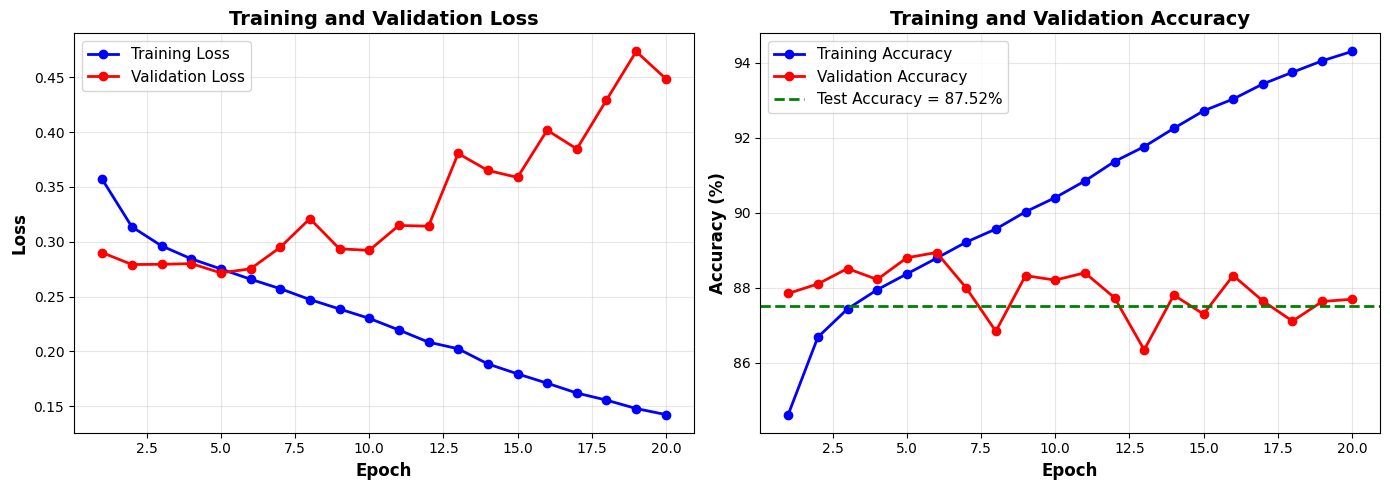


SUMMARY
Final Training Accuracy:   94.30%
Final Validation Accuracy: 87.69%
Test Accuracy:             87.52%
Test Loss: 0.3111
Test Accuracy: 87.52%

TRAINING COMPLETED!
✓ Best Validation Accuracy: 88.94%
✓ Test Accuracy: 87.52%
✓ Model saved as 'Models/Breast_Cancer.pth'


In [11]:
model, train_accs, val_accs, test_acc = train_model(
    base_path=base_path,
    num_epochs=20,          # Number of times to go through all data
    batch_size=64,          # Number of images per batch
    learning_rate=0.001     # How fast the model learns
)